# Check data for the spatial transcriptome dataset

Data source: https://www.10xgenomics.com/cn/datasets/human-ovarian-cancer-11-mm-capture-area-ffpe-2-standard

# 1) Check image and count data

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import skimage
import skimage.io
import skimage.transform
import tifffile

In [2]:
import scanpy
import scipy

(41048, 30035, 3)


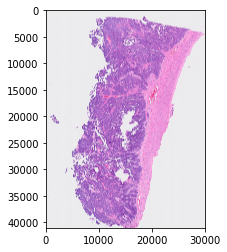

In [9]:
# Directories for images, count files, and transformation matrices.
# These can be downloaded from the provided link or accessed from the sample dataset.

image_file = "./Sample_data/Dataset_HOC/5_CytAssist_11mm_FFPE_Human_Ovarian_Carcinoma_tissue_image.tif"

image = tifffile.imread(os.path.join(image_file))
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [11]:
### 1.2 Read the ST data

### 1.2.1 The gene expression matrix
gene_matrix = scanpy.read_mtx("./Sample_data/Dataset_HOC/matrix.mtx")

### 1.2.2. The spatial barcodes matrix

barcodes = pd.read_csv('./Sample_data/Dataset_HOC/barcodes.tsv', 
                       header=None)
### 1.2.3. The gene features matrix

genes = pd.read_csv('./Sample_data/Dataset_HOC/features.tsv', 
                       header=None, sep='\t')

In [15]:

pd_meta = pd.read_csv('./Sample_data/Dataset_HOC/meta_df.csv', index_col=0)
pd_meta = pd_meta[['pxl_row_in_fullres', 'pxl_col_in_fullres']].copy()
pd_meta.columns = ['X', 'Y']
# Keep only rows where both x and y are >= 0
mask = (pd_meta['X'] >= 0) & (pd_meta['Y'] >= 0)

pd_meta = pd_meta[mask]
pd_meta

,X,Y
barcode,,
AACAATGTGCTCCGAG-1,29958,4830
AACACCATTCGCATAC-1,15758,8366
AACACGTTGATACCGC-1,25910,17813
AACACTCGTGAGCTTC-1,27140,10504
AACAGCCTCCTGACTA-1,31887,12125
...,...,...
TGTTGCTATCGGTGGC-1,39153,12639
TGTTGGCCTGTAGCGG-1,11706,19523
TGTTGGTGCGCACGAG-1,6626,14069


# 2) Create count data

In [16]:

count = scipy.sparse.csr_matrix.toarray(gene_matrix.X)
count = count.T

count_df = pd.DataFrame(count.astype(int), columns=genes.loc[:, 1].values, index=barcodes.loc[:, 0].values)

In [17]:
count_df

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
AACAATGTGCTCCGAG-1,3,12,0,0,0,0,2,54,1,1,...,73,127,175,102,28,79,117,22,8,41
AACACCATTCGCATAC-1,3,5,1,2,0,1,20,27,0,0,...,84,101,90,86,0,69,83,5,9,50
AACACGTTGATACCGC-1,5,6,3,0,0,2,0,40,0,0,...,111,158,316,143,32,108,163,29,7,78
AACACTCGTGAGCTTC-1,13,6,2,2,1,2,7,45,0,1,...,90,150,279,157,36,61,187,25,15,82
AACAGCCTCCTGACTA-1,12,9,0,2,0,4,4,33,0,4,...,97,148,230,128,38,83,179,39,18,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGCTATCGGTGGC-1,3,7,1,0,0,1,21,15,0,1,...,88,133,176,102,28,92,112,27,8,48
TGTTGGCCTGTAGCGG-1,4,10,1,2,0,2,18,48,0,3,...,148,181,357,178,34,153,210,15,10,97
TGTTGGTGCGCACGAG-1,5,0,0,0,0,2,18,14,0,0,...,17,7,25,8,0,6,10,2,0,6
TGTTGGTGCGGAATCA-1,11,18,2,4,0,0,4,37,0,3,...,108,230,376,170,40,98,192,28,18,75


In [18]:
count_df.to_csv('./output/Dataset_HOC/count_df.csv')

In [ ]:
### process the count file

In [14]:

# Remove 0s
print(count_df.shape)
gene_sum = np.sum(count_df, axis=0)
gene_names = gene_sum.index.values[gene_sum > 0]
count_df = count_df.loc[:, gene_names]
print(count_df.shape)

# Sum replicate columns
from tqdm import tqdm
gene_names_unique = []
for gene_name in tqdm(list(set(count_df.columns.values))):
    if sum([_ == gene_name for _ in count_df.columns.values]) > 1:
        # count_df_new.loc[:, gene_name] = np.sum(count_df.loc[:, gene_name], axis=1)
        pass
    else:
        gene_names_unique.append(gene_name)
count_df_new = count_df.loc[:, gene_names_unique].copy()
for gene_name in tqdm(list(set(count_df.columns.values))):
    if gene_name not in gene_names_unique:
        count_df_new.loc[:, gene_name] = np.sum(count_df.loc[:, gene_name], axis=1)

# CPM normalization
count_norm_df = count_df_new.copy().astype(float)
for n_row in tqdm(range(len(count_df_new))):
    count_norm_df.loc[count_norm_df.index.values[n_row], :] = count_df_new.iloc[n_row, :].values / np.sum(count_df_new.iloc[n_row, :].values)\
                                   * 1000000

(4674, 18085)
(4674, 18070)


100%|██████████| 4674/4674 [00:58<00:00, 79.52it/s]


In [60]:

count_norm_df

,EMC10,ARHGEF28,NUDT2,ITPR3,TMEM151B,CSKMT,DYNLL1,CENPQ,MSH6,HTR2B,...,CYTH4,SNAPC3,TYMP,CPTP,WBP2,OR7C2,SV2B,HSPA14,TBCE,TMSB15B
barcode,,,,,,,,,,,,,,,,,,,,,
AACAATGTGCTCCGAG-1,71.293623,0.000000,0.000000,106.940434,0.000000,35.646811,0.000000,35.646811,142.587246,0.000000,...,0.000000,35.646811,0.000000,106.940434,71.293623,0.000000,0.0,213.880868,285.174491,71.293623
AACACCATTCGCATAC-1,45.762402,0.000000,45.762402,137.287205,0.000000,0.000000,0.000000,45.762402,91.524803,0.000000,...,0.000000,45.762402,228.812008,45.762402,0.000000,0.000000,0.0,91.524803,0.000000,0.000000
AACACGTTGATACCGC-1,177.529800,0.000000,25.361400,126.807000,0.000000,25.361400,101.445600,25.361400,152.168400,0.000000,...,25.361400,76.084200,25.361400,152.168400,25.361400,0.000000,0.0,202.891200,253.613999,0.000000
AACACTCGTGAGCTTC-1,226.598083,22.659808,22.659808,113.299041,0.000000,0.000000,67.979425,45.319617,181.278466,22.659808,...,0.000000,22.659808,113.299041,45.319617,22.659808,22.659808,0.0,181.278466,498.515783,0.000000
AACAGCCTCCTGACTA-1,151.718757,65.022324,43.348216,238.415189,0.000000,65.022324,65.022324,43.348216,65.022324,43.348216,...,43.348216,173.392865,21.674108,65.022324,21.674108,0.000000,0.0,86.696432,216.741081,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGCTATCGGTGGC-1,240.009600,30.001200,0.000000,60.002400,0.000000,0.000000,60.002400,0.000000,60.002400,0.000000,...,0.000000,90.003600,180.007200,210.008400,30.001200,0.000000,0.0,180.007200,360.014401,60.002400
TGTTGGCCTGTAGCGG-1,166.285596,20.785699,20.785699,166.285596,0.000000,20.785699,62.357098,0.000000,187.071295,20.785699,...,0.000000,124.714197,20.785699,124.714197,41.571399,0.000000,0.0,124.714197,124.714197,0.000000
TGTTGGTGCGCACGAG-1,135.492175,0.000000,0.000000,67.746088,0.000000,67.746088,67.746088,0.000000,135.492175,0.000000,...,67.746088,0.000000,67.746088,135.492175,0.000000,0.000000,0.0,135.492175,0.000000,0.000000


In [17]:
count_norm_df.to_csv("./output/Dataset_HOC/1_pd_count_norm_ovarian.csv", index=True)

In [21]:
count_stat = pd.DataFrame(columns=count_norm_df.columns.values, index=["mean", "std", "tile_95", "non_zero_p", "max"])
count_stat.loc['mean', :] = np.average(count_norm_df, axis=0)
count_stat.loc['std', :] = np.std(count_norm_df, axis=0)
count_stat.loc['tile_95', :] = np.quantile(count_norm_df, 0.95, axis=0)
count_stat.loc['non_zero_p', :] = np.sum(np.array(count_norm_df) > 0, axis=0)/count_norm_df.shape[0]
count_stat.loc['max', :] = np.max(count_norm_df, axis=0)

In [22]:
count_stat.to_csv("./output/Dataset_HOC/1_count_stat_ovarian.csv")

# Session Info

In [36]:
!pip freeze

argon2-cffi @ file:///tmp/build/80754af9/argon2-cffi_1613037492802/work
async-generator==1.10
attrs @ file:///opt/conda/conda-bld/attrs_1642510447205/work
backcall @ file:///home/ktietz/src/ci/backcall_1611930011877/work
bleach @ file:///opt/conda/conda-bld/bleach_1641577558959/work
cached-property==1.5.2
certifi==2021.5.30
cffi @ file:///tmp/build/80754af9/cffi_1625814693874/work
charset-normalizer==2.0.12
cycler==0.11.0
decorator==4.4.2
defusedxml @ file:///tmp/build/80754af9/defusedxml_1615228127516/work
entrypoints==0.3
googledrivedownloader==0.4
idna==3.10
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.15.0
importlib-metadata @ file:///tmp/build/80754af9/importlib-metadata_1631916693255/work
importlib-resources==5.4.0
ipykernel==5.5.6
ipython @ file:///tmp/build/80754af9/ipython_1593447367857/work
ipython-genutils==0.2.0
jedi==0.17.2
Jinja2 @ file:///opt/conda/conda-bld/jinja2_1647436528585/work
jsonschema @ file:///Users/ktietz/demo/mc3/conda-bld/jsonschema_1630511